In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Rows Columns
(81, 4)
   Age  Number  Start  class
0   71       3      5      0
1  158       3     14      0
2  128       4      5      1
3    2       5      1      0
4    1       4     15      0

 class
0    64
1    17
Name: count, dtype: int64


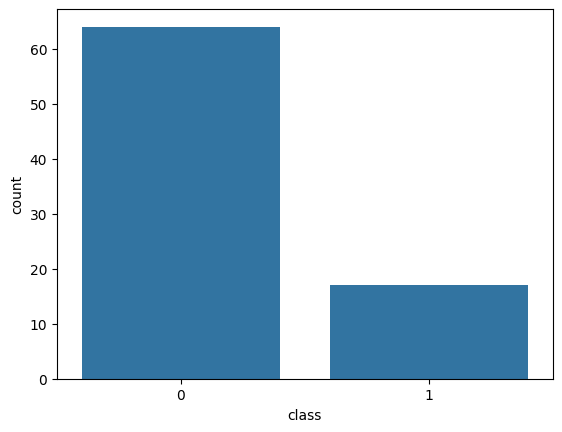

In [2]:
#Read and Display Data Set

#First, read in CSV and assign it to a variable called "data"
data = pd.read_csv("data/kyphosis.csv")

#Second, display maximum rows and columns
print('\nRows Columns') #Indicates rows and columns
print(data.shape) #gets the number of rows and columns of data set

pd.set_option('display.max_columns', None) #optional setting to show all feature columns

#Third, display first five rows to check data
print(data.head(5))

#Select last column (assuming the last column is the class)
last_column = data.iloc[:, -1] #using iloc to select the last column

#Count occurences of 0's and 1's
value_counts = last_column.value_counts()

#Print the value counts and check for imbalance
print('\n' , value_counts)

sns.countplot(x="class", data=data)
plt.show()

In [ ]:
#Display Feature Relations of Data Set
plt.figure(figsize=(20,20)) #Adjust width and height
print(sns.heatmap(data.corr(),annot=True, annot_kws={"size":16}, cmap= sns.cm.rocket_r))

In [5]:
#Declare X and Y Variables and Split the Dataset into Train and Test sections
X=data.drop(['class'], axis=1).values #X Variables = all common except the last one

#Declare last column to be the Dependent variable Y
y=data['class'].values #Y Variable = last column

#Split Data Set 70% training and 30% Testing. Initial data shuffle to zero
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7,test_size=0.3, random_state=0)

In [8]:
#Create and Test the Model

#First, declare a new model
classifier_model = DecisionTreeClassifier()

#Second, Train (fit) the model from the training data
classifier_model.fit(X_train, y_train)

#Fourth, Test the model using the testing data
y_pred = classifier_model.predict(X_test)
print('\nTest Data Model = ', y_pred)


Test Data Model =  [0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 1]


In [9]:
#Create and test random forest model
from sklearn.ensemble import RandomForestClassifier as RandomForest
rf = RandomForest(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('\nRandom Forest Model = ', y_pred_rf)

#Evaluate the Model
from sklearn.metrics import classification_report
print('\nDecision Tree Classifier Model')
print(classification_report(y_test, y_pred))
print('\naccuracy_score = ', accuracy_score(y_test, y_pred))
print('precision_score = ', precision_score(y_test, y_pred))
print('recall_score = ', recall_score(y_test, y_pred))
print('f1_score = ', f1_score(y_test, y_pred))
print('confusion_matrix = ', confusion_matrix(y_test, y_pred))



Random Forest Model =  [0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0]

Decision Tree Classifier Model
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        18
           1       0.67      0.57      0.62         7

    accuracy                           0.80        25
   macro avg       0.75      0.73      0.74        25
weighted avg       0.79      0.80      0.80        25


accuracy_score =  0.8
precision_score =  0.6666666666666666
recall_score =  0.5714285714285714
f1_score =  0.6153846153846154
confusion_matrix =  [[16  2]
 [ 3  4]]


In [ ]:
#Evaluate Model
print('\nConfusion Matrix = \n', confusion_matrix(y_test, y_pred))
print('\nAccuracy = ', accuracy_score(y_test, y_pred))
print('\nPrecision = ', precision_score(y_test, y_pred))
print('\nRecall = ', recall_score(y_test, y_pred))
print('\nF1 Score = ', f1_score(y_test, y_pred))

#Print out shape of tree
from sklearn.tree import _tree, plot_tree
plt.figure('Decision Tree', figsize=(70,40))
plot_tree(classifier_model, filled=True, rounded=True, fontsize=14, feature_names=data.columns, class_names=['Poisonous','Edible'])
plt.show()